In [1]:
pip install xgboost lightgbm catboost joblib

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   - -------------------------------------- 2.1/48.9 MB 8.4 MB/s eta 0:00:06
   -- ------------------------------------- 2.9/48.9 MB 8.6 MB/s eta 0:00:06
   --- ------------------------------------ 4.5/48.9 MB 7.2 MB/s eta 0:00:07
   ---- ----------------------------------- 5.0/48.9 MB 5.6 MB/s eta 0:00:08
   ----- ---------------------------------- 6.3/48.9 MB 5.6 MB/s eta 0:00:08
   ----- ---------------------------------- 7.1/48.9 MB 5.6 MB/s eta 0:00:08
   ------- -------------------------------- 9.2/48.9 MB 6.0 MB/s eta 0:00:07
   -------- ------------------------------- 10.5/48.9 MB 6.1 MB/s eta 0:00:07
   --------- ------------------------------ 11.8/48.9 MB 6.0 MB/s eta 0:00:07
   ---------- ----------------------------- 12.8/48.9 MB 6.1 MB/s eta 0:00:06
   ----------- ---------------------------- 14.4/48.9 MB 6.0 MB/s eta 0:00:06
   ------

In [2]:
import os
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv("../data/processed/bdhs_2022_encoded.csv")
X = df.drop('c_section', axis=1)
y = df['c_section']

# 2. Split Data (Stratified 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Normalize ALL features for SVM and Logistic Regression compatibility
scaler = StandardScaler()
# Keeping as DataFrames to preserve column names for SHAP explainability later
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Create models directory and save the scaler
os.makedirs("../src/models", exist_ok=True)
joblib.dump(scaler, "../src/models/standard_scaler.pkl")

# 4. Setup 10-Fold Cross Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 5. Define Models and Hyperparameter Grids
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42), 
        {'C': [0.1, 1.0, 10.0]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42), 
        {'n_estimators': [100, 200], 'max_depth': [10, None]}
    ),
    "SVM": (
        SVC(probability=True, random_state=42), 
        {'C': [0.1, 1.0], 'kernel': ['linear', 'rbf']}
    ),
    "XGBoost": (
        XGBClassifier(eval_metric='logloss', random_state=42), 
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
    ),
    "LightGBM": (
        LGBMClassifier(random_state=42, verbose=-1), 
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
    ),
    "CatBoost": (
        CatBoostClassifier(random_state=42, verbose=0), 
        {'iterations': [100, 200], 'learning_rate': [0.05, 0.1], 'depth': [4, 6]}
    )
}

# 6. Grid Search & Training Loop
best_estimators = {}
results = []

print("Starting 10-Fold CV Grid Search for base models...\n")
print("-" * 60)

for name, (model, params) in models.items():
    print(f"Tuning and Training: {name}...")
    
    grid = GridSearchCV(model, params, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    # Save the individual tuned model
    model_filename = f"../src/models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(best_model, model_filename)
    
    # Evaluate on the test set
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# 7. Stack Ensemble (Meta-Model)
print("\nTraining Stacked Ensemble...")
estimators = [(name, model) for name, model in best_estimators.items()]
stacked_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=cv, n_jobs=-1)

stacked_model.fit(X_train, y_train)
y_pred_stack = stacked_model.predict(X_test)
y_prob_stack = stacked_model.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Stacked Ensemble",
    "Accuracy": accuracy_score(y_test, y_pred_stack),
    "Precision": precision_score(y_test, y_pred_stack),
    "Recall": recall_score(y_test, y_pred_stack),
    "F1-Score": f1_score(y_test, y_pred_stack),
    "ROC-AUC": roc_auc_score(y_test, y_prob_stack)
})

# Save the Stacked Ensemble
joblib.dump(stacked_model, "../src/models/stacked_ensemble.pkl")

# 8. Display and Save Metrics
results_df = pd.DataFrame(results)
print("\nFinal Evaluation Results (Test Set):")
display(results_df)
results_df.to_csv("../data/processed/model_full_cv_results.csv", index=False)
print("\nSuccess! All models and the scaler have been saved to the ../src/models/ directory.")

Starting 10-Fold CV Grid Search for base models...

------------------------------------------------------------
Tuning and Training: Logistic Regression...
Tuning and Training: Random Forest...
Tuning and Training: SVM...
Tuning and Training: XGBoost...
Tuning and Training: LightGBM...
Tuning and Training: CatBoost...

Training Stacked Ensemble...

Final Evaluation Results (Test Set):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.859419,0.813102,0.888421,0.849095,0.931454
1,Random Forest,0.865042,0.829026,0.877895,0.852761,0.924591
2,SVM,0.856607,0.813230,0.880000,0.845298,0.911358
3,XGBoost,0.862231,0.822835,0.880000,0.850458,0.933032
4,LightGBM,0.861293,0.821218,0.880000,0.849593,0.933142
5,CatBoost,0.860356,0.817121,0.884211,0.849343,0.932055
6,Stacked Ensemble,0.857545,0.821074,0.869474,0.844581,0.934008



Success! All models and the scaler have been saved to the ../src/models/ directory.


Saved ROC Curves to: ../figures/fig5_roc_curves.png


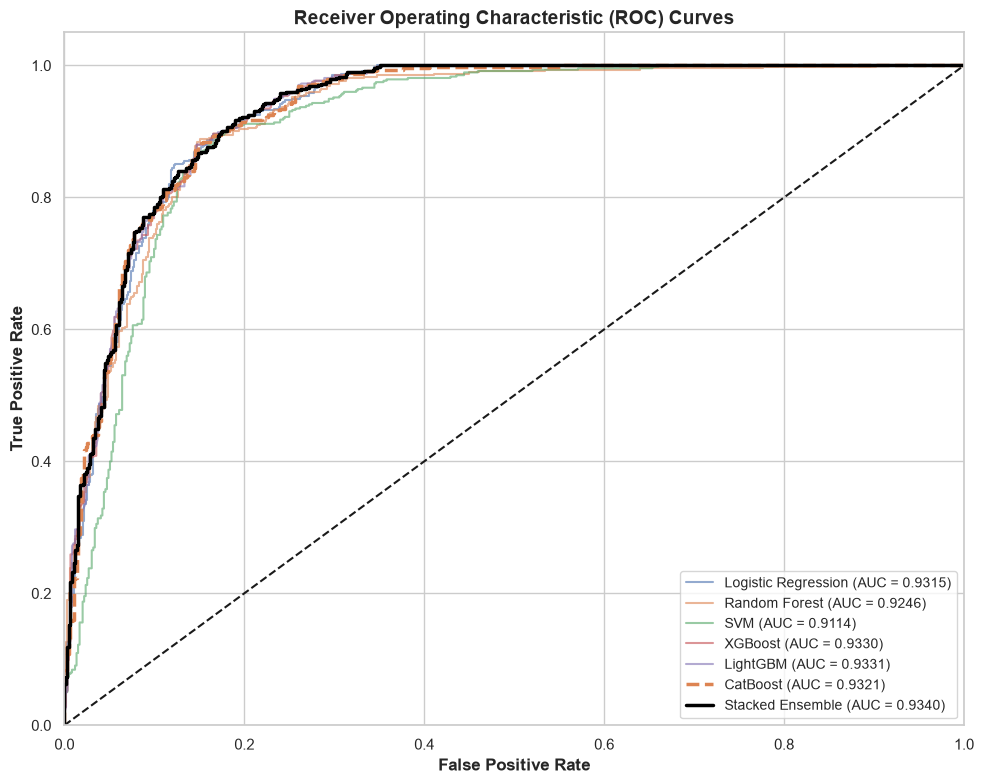

Saved Confusion Matrices to: ../figures/fig6_confusion_matrices.png


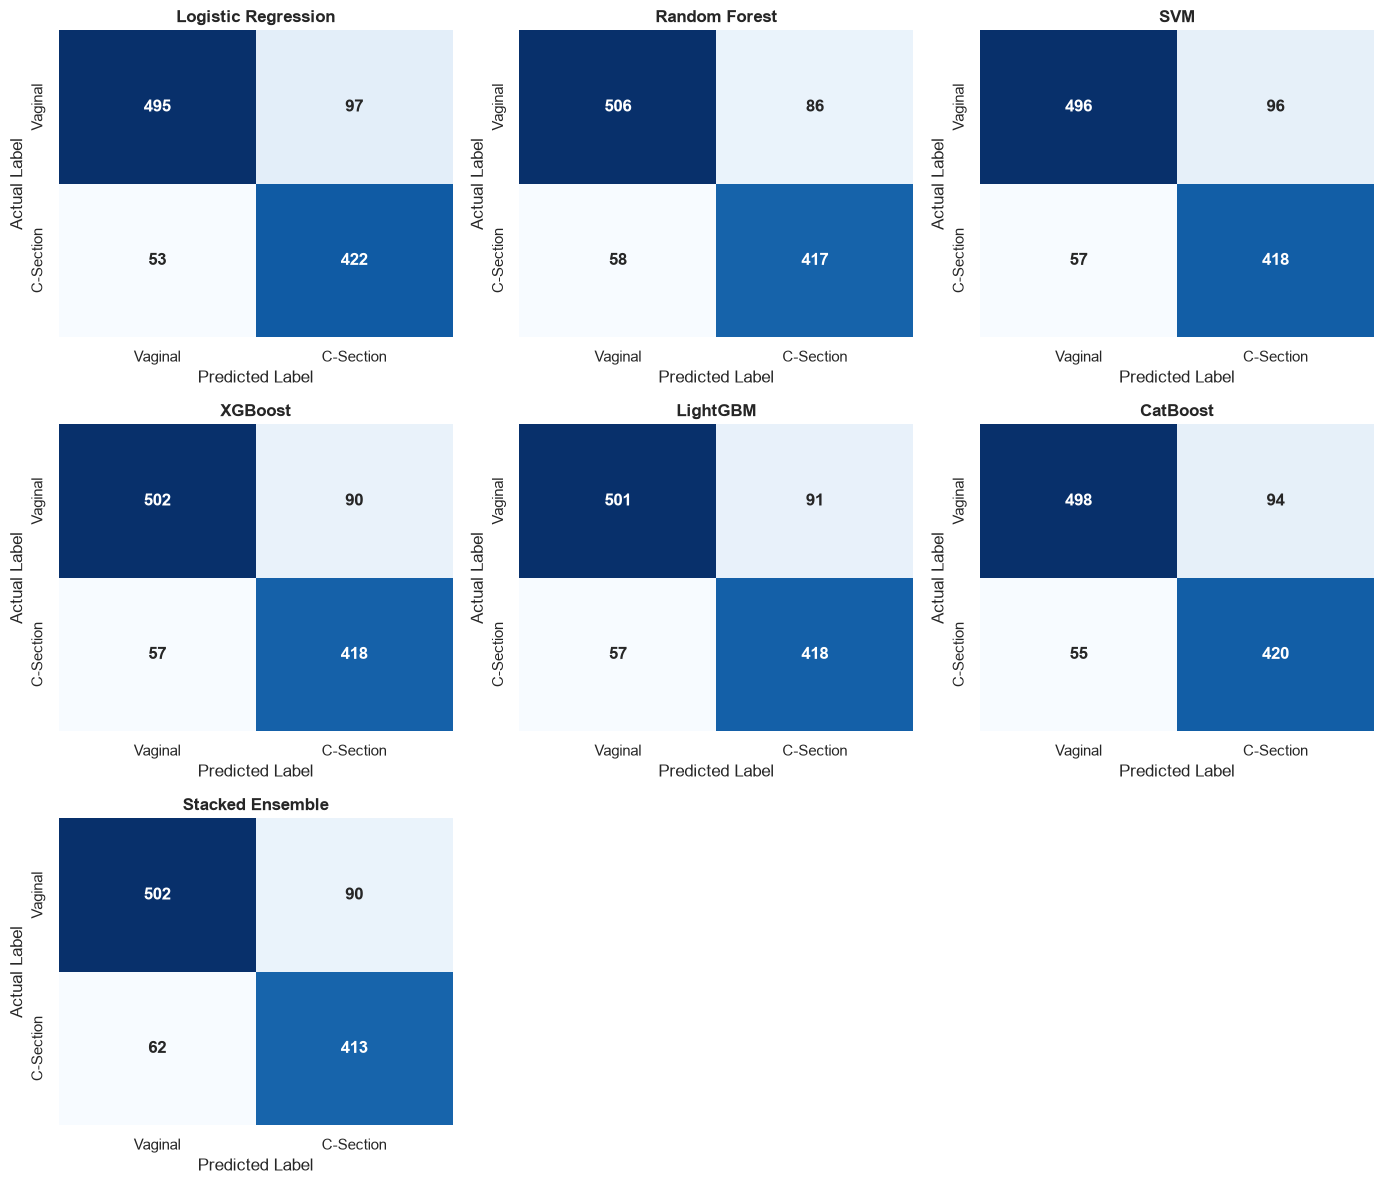

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
import os

# Ensure the figures directory exists
os.makedirs("../figures", exist_ok=True)
sns.set_theme(style="whitegrid")

# Combine the base estimators and the stacked model into one dictionary
models_to_plot = {**best_estimators, "Stacked Ensemble": stacked_model}

# ==========================================
# Figure 5: Unified ROC Curves
# ==========================================
plt.figure(figsize=(10, 8))

for name, model in models_to_plot.items():
    # Get predicted probabilities for the positive class (C-Section)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Highlight the Stacked Ensemble and CatBoost (our SHAP candidate)
    if name == "Stacked Ensemble":
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2.5, color='black')
    elif name == "CatBoost":
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2.5, linestyle='--', color='#DD8452')
    else:
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=1.5, alpha=0.6)

# Plot the random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, weight='bold')
plt.ylabel('True Positive Rate', fontsize=12, weight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, weight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()

# Save ROC figure
plt.savefig("../figures/fig5_roc_curves.png", dpi=300)
print("Saved ROC Curves to: ../figures/fig5_roc_curves.png")
plt.show()

# ==========================================
# Figure 6: Confusion Matrix Grid
# ==========================================
# Create a 3x3 grid for the 7 models
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_to_plot.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Vaginal', 'C-Section'], 
                yticklabels=['Vaginal', 'C-Section'],
                annot_kws={"size": 12, "weight": "bold"})
    
    axes[idx].set_title(f'{name}', fontsize=12, weight='bold')
    axes[idx].set_ylabel('Actual Label')
    axes[idx].set_xlabel('Predicted Label')

# Hide the last two empty subplots (since we have 7 models for 9 slots)
for i in range(7, 9):
    fig.delaxes(axes[i])

plt.tight_layout()

# Save Confusion Matrix figure
plt.savefig("../figures/fig6_confusion_matrices.png", dpi=300)
print("Saved Confusion Matrices to: ../figures/fig6_confusion_matrices.png")
plt.show()

In [5]:
pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/41.9 MB 8.4 MB/s eta 0:00:05
   --- ------------------------------------ 3.4/41.9 MB 9.0 MB/s eta 0:00:05
   ---- ----------------------------------- 5.0/41.9 MB 8.0 MB/s eta 0:00:05
   ----- ---------------------------------- 6.0/41.9 MB 7.3 MB/s eta 0:00:05
   ------ --------------------------------- 6.8/41.9 MB 6.6 MB/s eta 0:00:06
   ------- -------------------------------- 7.9/41.9 MB 6.5 MB/s eta 0:00:06
   -------- ------------------------------- 9.2/41.9 MB 6.4 MB/s eta 0:00:06
   --------- ------------------------------ 10.0/41.9 MB 6.2 MB/s eta 0:00:06
   ---------- ----------------------------- 11.0/41.9 MB 5.9 MB/s eta 0:00:06
   ----------- ---------------------------- 12.1/41.9 MB 5.9 MB/s eta 0:00:06
   ------------ --------------------------- 13.1/41.9 MB 5.9 MB/s eta 0:00:05
   ------------- -------------------------- 14.4/41.9 MB 5.9 MB/s eta 0:00:05
 

Background dataset has 4264 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4264 when initializing the masker.


Starting Universal SHAP Analysis...

Generating SHAP plots for: Logistic Regression
Generating SHAP plots for: Random Forest
Generating SHAP plots for: SVM
  -> Note: Using KernelExplainer for SVM (Running on sampled subset to save time).
Generating SHAP plots for: XGBoost
Generating SHAP plots for: LightGBM
Generating SHAP plots for: CatBoost
Generating SHAP plots for: Stacked Ensemble
  -> Note: Using KernelExplainer for Stacked Ensemble (Running on sampled subset to save time).

Success! All 14 SHAP figures have been saved in: ../figures/shap_all_models/


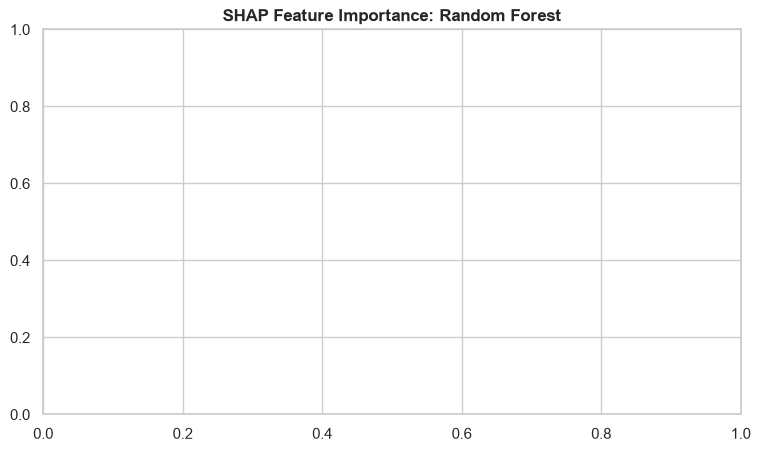

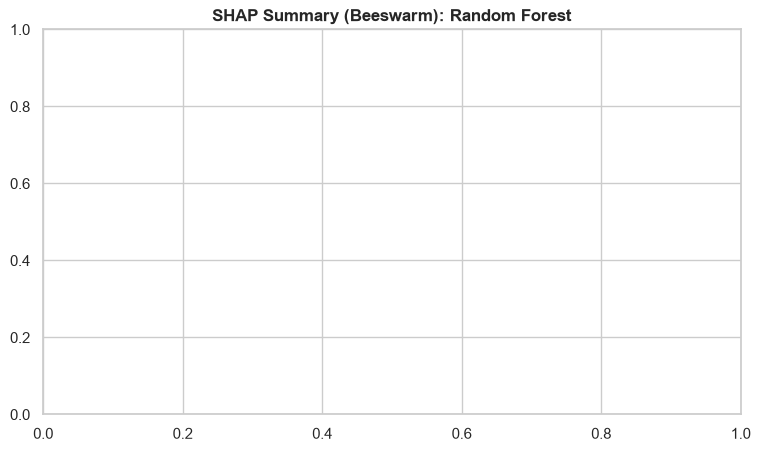

In [7]:
import shap
import matplotlib.pyplot as plt
import os
import warnings

# Suppress SHAP warnings for cleaner output
warnings.filterwarnings('ignore')
os.makedirs("../figures/shap_all_models", exist_ok=True)

# Define models to process (Assuming 'models_to_plot' and data are still in memory)
models_to_plot = {**best_estimators, "Stacked Ensemble": stacked_model}

# Create a small background dataset for the slow models to prevent crashing
background_summary = shap.kmeans(X_train, 10)
X_test_sampled = X_test.sample(100, random_state=42)

print("Starting Universal SHAP Analysis...\n")

for name, model in models_to_plot.items():
    print(f"Generating SHAP plots for: {name}")
    
    try:
        # 1. Tree Models
        if name in ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)
            
            # Handle shape differences: Some algorithms output lists for binary classification
            if isinstance(shap_values, list):
                shap_values_to_plot = shap_values[1] # Index 1 is the positive class (C-Section)
            else:
                shap_values_to_plot = shap_values
            
            data_to_plot = X_test

        # 2. Linear Models
        elif name == "Logistic Regression":
            explainer = shap.LinearExplainer(model, X_train)
            shap_values_to_plot = explainer.shap_values(X_test)
            data_to_plot = X_test

        # 3. Black-Box Models (SVM, Stacked Ensemble)
        else:
            print(f"  -> Note: Using KernelExplainer for {name} (Running on sampled subset to save time).")
            # For KernelExplainer, we explain the predict_proba for the positive class
            def predict_fn(X):
                return model.predict_proba(X)[:, 1]
            
            explainer = shap.KernelExplainer(predict_fn, background_summary)
            shap_values_to_plot = explainer.shap_values(X_test_sampled, silent=True)
            data_to_plot = X_test_sampled

        # ==========================================
        # Plot A: Global Feature Importance (Bar Plot)
        # ==========================================
        plt.figure(figsize=(9, 5))
        plt.title(f"SHAP Feature Importance: {name}", fontsize=12, weight='bold')
        shap.summary_plot(shap_values_to_plot, data_to_plot, plot_type="bar", show=False, color='#4C72B0')
        plt.tight_layout()
        filename_bar = f"../figures/shap_all_models/{name.replace(' ', '_').lower()}_bar.png"
        plt.savefig(filename_bar, dpi=300, bbox_inches='tight')
        plt.close() # Close figure to free up memory

        # ==========================================
        # Plot B: Summary Beeswarm Plot
        # ==========================================
        plt.figure(figsize=(9, 5))
        plt.title(f"SHAP Summary (Beeswarm): {name}", fontsize=12, weight='bold')
        shap.summary_plot(shap_values_to_plot, data_to_plot, show=False, cmap='magma')
        plt.tight_layout()
        filename_swarm = f"../figures/shap_all_models/{name.replace(' ', '_').lower()}_swarm.png"
        plt.savefig(filename_swarm, dpi=300, bbox_inches='tight')
        plt.close()
        
    except Exception as e:
        print(f"  -> Error generating SHAP for {name}: {str(e)}")

print("\nSuccess! All 14 SHAP figures have been saved in: ../figures/shap_all_models/")

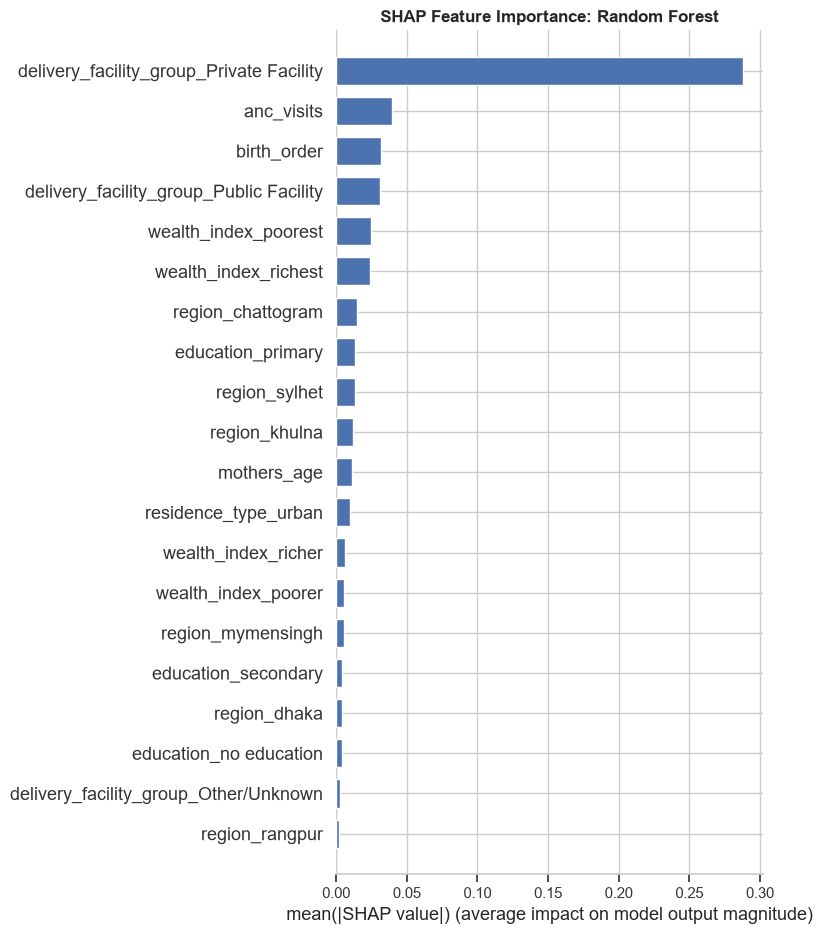

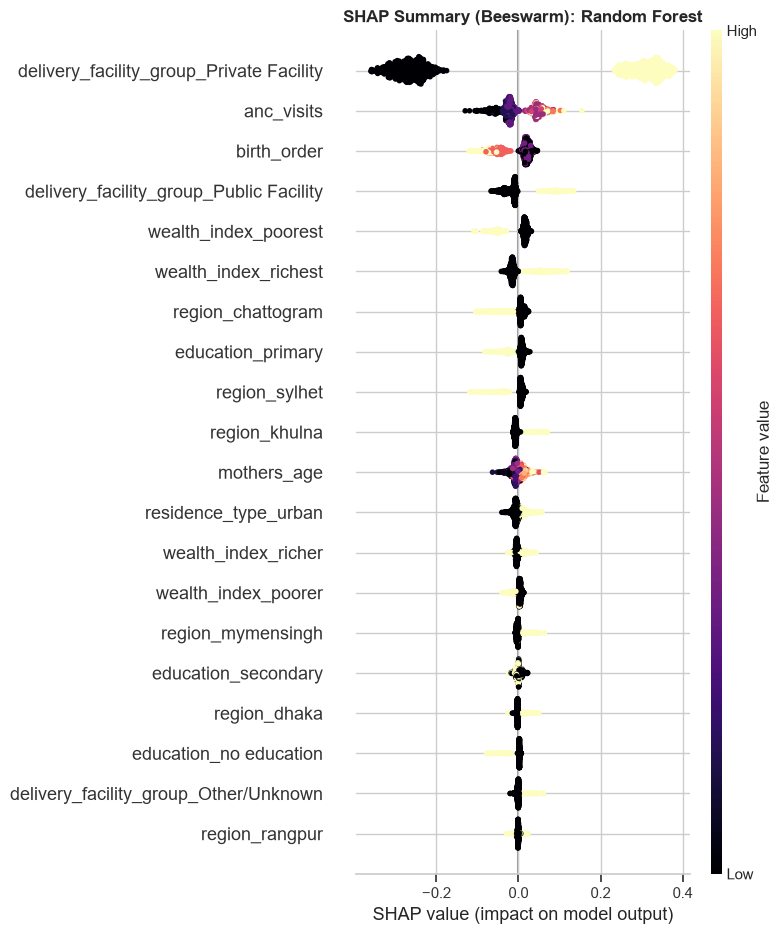

In [9]:
##Random forest corrupted shap fix:
import shap
import matplotlib.pyplot as plt

# 1. Get the Random Forest model
rf_model = best_estimators["Random Forest"]

# 2. Initialize Explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# 3. The crucial fix: Check if it's a 3D array and slice the positive class
if len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# ==========================================
# Generate Correct Bar Plot
# ==========================================
plt.figure(figsize=(9, 5))
plt.title("SHAP Feature Importance: Random Forest", fontsize=12, weight='bold')
shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar", show=False, color='#4C72B0')
plt.tight_layout()
plt.savefig("../figures/shap_all_models/random_forest_bar.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# Generate Correct Beeswarm Plot
# ==========================================
plt.figure(figsize=(9, 5))
plt.title("SHAP Summary (Beeswarm): Random Forest", fontsize=12, weight='bold')
shap.summary_plot(shap_values_to_plot, X_test, show=False, cmap='magma')
plt.tight_layout()
plt.savefig("../figures/shap_all_models/random_forest_swarm.png", dpi=300, bbox_inches='tight')
plt.show()